# El 85% de las ciudades chinas sintió un calor que solo el 52% sufrió

Entre 2010 y 2024, el 52,1% de las ciudades de China pasó olas de calor físicamente severas. Pero el 84,9% recibió un golpe emocional de alta intensidad. ¿Cómo llega la angustia a más lugares que el calor?

:::{image} figuras/pixabot.png
:alt: Pixabot mascot
:width: 80px
:align: center
:figclass: pixabot-mascot
:::

**Paper:** Zhou et al. (2026). *Divergence between physical and emotional heat resilience in Chinese cities*. **Nature Climate Change**

**DOI:** [10.1038/s41558-026-02732-8](https://doi.org/10.1038/s41558-026-02732-8)

[![Abrir en Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Ciencia-a-Mordiscos/lab/blob/main/papers/2026-09-11-calor-emocional-ciudades-china/notebook.ipynb)

**Video:** [Pendiente]

## Dos termómetros para la misma ola de calor

El equipo cruzó 11 millones de comentarios geolocalizados de Weibo (la red social china) con la temperatura de ERA5-Land (una base meteorológica global, reconstruida por rejilla), en 357 ciudades y durante 15 veranos. De ahí salen dos índices, ambos de 0 a 1 y con la misma lectura — más alto, más resiliente:

- **HGI**, resiliencia física: cuánto sube la temperatura en una ola de calor y cuánto tarda en bajar.
- **EGI**, resiliencia emocional: cuánto cae el ánimo expresado en redes y cuánto tarda en recuperarse.

Una ciudad cuenta como *vulnerable* cuando queda por encima de la media nacional en intensidad o en tiempo de recuperación. Es un estudio observacional: nadie manipuló nada, así que lo que sigue son patrones, no causas. Los datos que usamos aquí vienen del texto del paper (acceso abierto) y de su Supplementary Table 1; el dataset crudo pesa 892 MB y no lo abrimos.

In [1]:
# ══════════════════════════════════════════════════════════════
# Configuración — modifica estos valores para explorar
# ══════════════════════════════════════════════════════════════
LAT_CORTE = 30.0             # Latitud que separa "sur" de "norte" en la celda experimental
FUENTE = 'Fuente: Zhou et al. (2026), Nature Climate Change | Datos: texto del paper + Supplementary Table 1'
COLOR_DATOS = '#2563EB'      # azul CaM — datos principales / físico
COLOR_ALERTA = '#DC2626'     # rojo — emocional / alerta
COLOR_SECUNDARIO = '#059669' # emerald
COLOR_REFERENCIA = '#D97706' # amber — umbrales y referencias
COLOR_CONTEXTO = '#BBBBBB'   # gris

import os, urllib.request
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

BASE = 'https://raw.githubusercontent.com/Ciencia-a-Mordiscos/lab/main'
PAPER = 'papers/2026-09-11-calor-emocional-ciudades-china'

# Estilo CaM (local → fallback GitHub raw)
style_file = '../../cam.mplstyle'
if not os.path.exists(style_file):
    style_file = '/tmp/cam.mplstyle'
    if not os.path.exists(style_file):
        urllib.request.urlretrieve(f'{BASE}/cam.mplstyle', style_file)
plt.style.use(style_file)

# Datos (descarga automática si no están en local)
os.makedirs('datos', exist_ok=True)
os.makedirs('figuras', exist_ok=True)
ARCHIVOS = ['lag_emocional_ciudades.csv', 'indices_estratificados.csv',
            'vulnerabilidad_por_cluster.csv', 'lag_por_region.csv',
            'importancia_shap.csv', 'proyecciones_ssp.csv', 'trayectoria_2010_2024.csv']
for nombre in ARCHIVOS:
    if not os.path.exists(f'datos/{nombre}'):
        urllib.request.urlretrieve(f'{BASE}/{PAPER}/datos/{nombre}', f'datos/{nombre}')

ciudades = pd.read_csv('datos/lag_emocional_ciudades.csv')
indices = pd.read_csv('datos/indices_estratificados.csv')
clusters = pd.read_csv('datos/vulnerabilidad_por_cluster.csv')
lag_region = pd.read_csv('datos/lag_por_region.csv')
shap = pd.read_csv('datos/importancia_shap.csv')
proy = pd.read_csv('datos/proyecciones_ssp.csv')
trayectoria = pd.read_csv('datos/trayectoria_2010_2024.csv')

# Formato español: coma decimal, punto de miles
def es(x, dec=1):
    s = f'{x:,.{dec}f}'
    return s.replace(',', 'X').replace('.', ',').replace('X', '.')

nacional = clusters[clusters['ambito'] == 'Nacional (357)'].set_index('perfil')['pct_ciudades']
PCT_FISICO = nacional.filter(like='fisico').iloc[0]
PCT_EMOCIONAL = nacional.filter(like='emocional').iloc[0]

print(f'Ciudades en la Supplementary Table 1: {len(ciudades)}')
print(f'Lag emocional: media {es(ciudades.mejor_lag_dias.mean(), 2)} días · '
      f'mediana {es(ciudades.mejor_lag_dias.median(), 2)} · '
      f'IQR {es(ciudades.mejor_lag_dias.quantile(0.25), 2)}–{es(ciudades.mejor_lag_dias.quantile(0.75), 2)} · '
      f'rango {es(ciudades.mejor_lag_dias.min(), 1)}–{es(ciudades.mejor_lag_dias.max(), 1)}')
print(f'Nacional (357 ciudades): físicamente vulnerables {es(PCT_FISICO)}% · '
      f'emocionalmente vulnerables {es(PCT_EMOCIONAL)}% · cociente {es(PCT_EMOCIONAL / PCT_FISICO, 2)}×')
print()
print(clusters[['ambito', 'perfil', 'pct_ciudades']].to_string(index=False))

Ciudades en la Supplementary Table 1: 39
Lag emocional: media 2,92 días · mediana 2,90 · IQR 2,60–3,30 · rango 2,0–4,0
Nacional (357 ciudades): físicamente vulnerables 52,1% · emocionalmente vulnerables 84,9% · cociente 1,63×

               ambito                                                                perfil  pct_ciudades
       Nacional (357)                          fisico: alta intensidad o recuperacion lenta          52.1
 Middle Yangtze River                          fisico: alta intensidad o recuperacion lenta          76.8
  Yangtze River Delta                          fisico: alta intensidad o recuperacion lenta          71.7
       Nacional (357)                                   emocional: shock de alta intensidad          84.9
  Yangtze River Delta                              doble vulnerabilidad (HGI y EGI debiles)          55.9
 Middle Yangtze River doble vulnerabilidad o vulnerable fisico con EGI relativamente fuerte          91.8
Beijing-Tianjin-Hebei          

Aquí está.

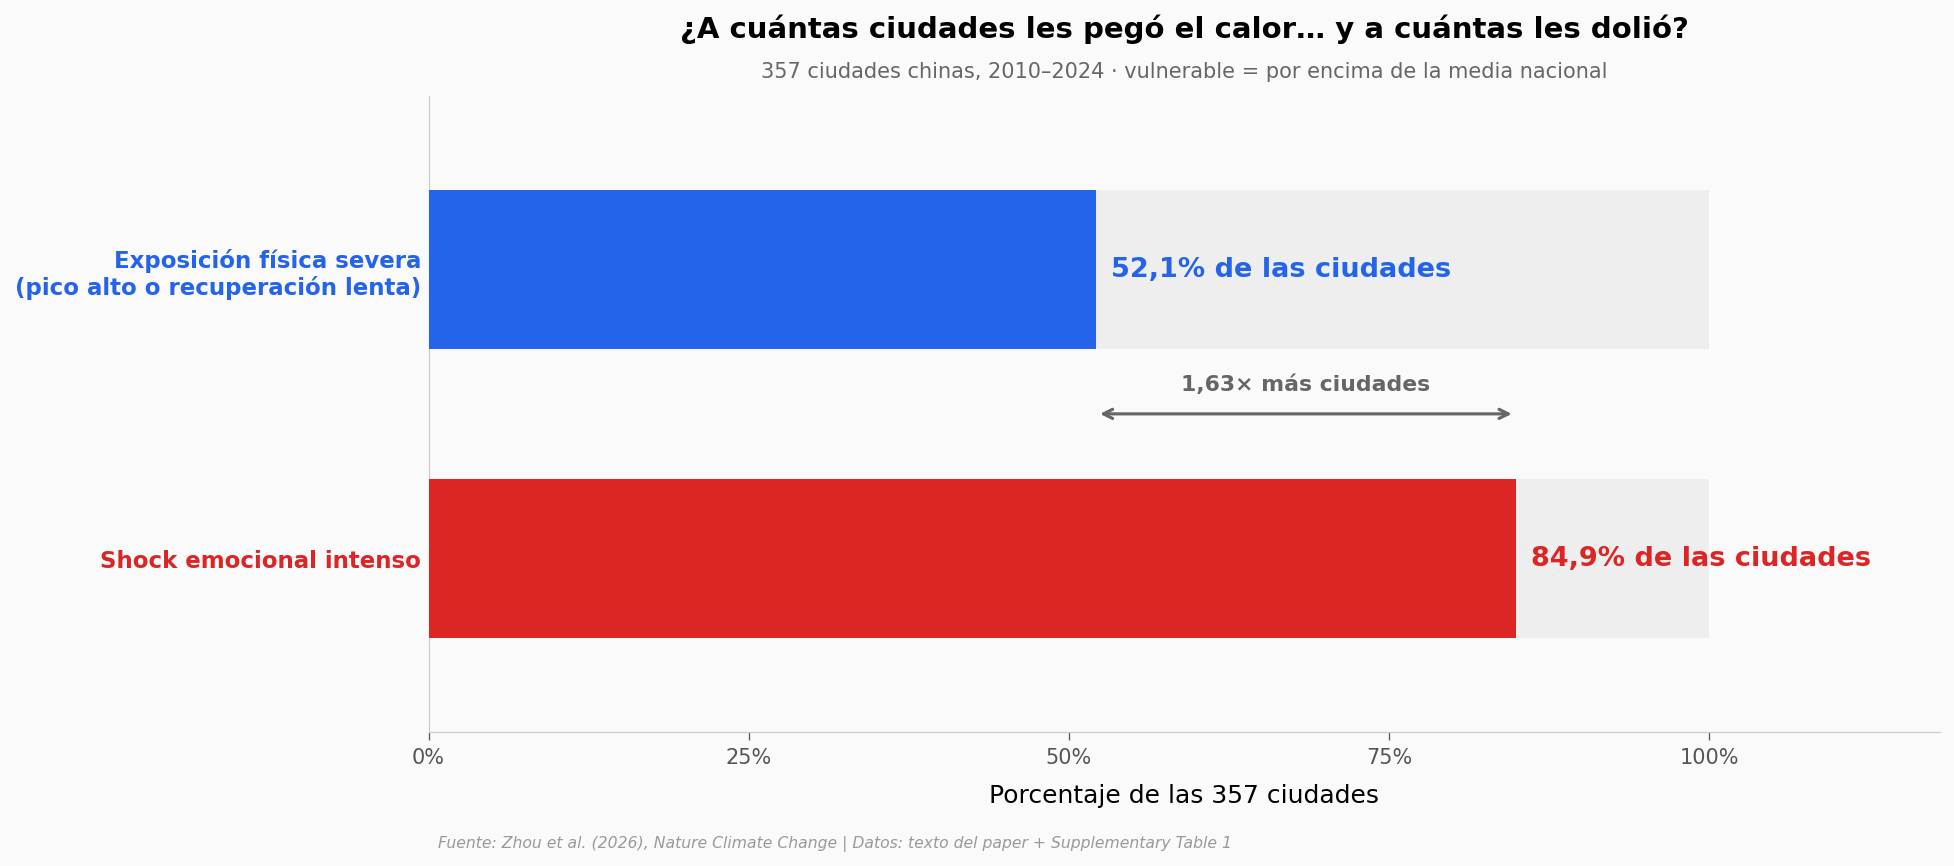

In [2]:
fig, ax = plt.subplots(figsize=(13, 5.5))

etiquetas = ['Exposición física severa\n(pico alto o recuperación lenta)',
             'Shock emocional intenso']
valores = [PCT_FISICO, PCT_EMOCIONAL]
colores = [COLOR_DATOS, COLOR_ALERTA]
y = [1, 0]

# Fondo gris = el 100% de las ciudades; barra de color = las vulnerables
ax.barh(y, [100, 100], height=0.55, color='#EEEEEE', zorder=2)
ax.barh(y, valores, height=0.55, color=colores, zorder=3)
for yi, v, c in zip(y, valores, colores):
    ax.text(v + 1.2, yi, f'{es(v)}% de las ciudades', va='center', ha='left',
            fontsize=13, fontweight='bold', color=c)

ax.set_yticks(y)
ax.set_yticklabels(etiquetas, fontsize=11, fontweight='bold')
for tick, c in zip(ax.get_yticklabels(), colores):
    tick.set_color(c)
ax.set_xlim(0, 118)
ax.set_xticks([0, 25, 50, 75, 100])
ax.set_xticklabels([f'{t}%' for t in [0, 25, 50, 75, 100]])
ax.set_xlabel('Porcentaje de las 357 ciudades')
ax.set_ylim(-0.6, 1.6)
ax.grid(axis='y', visible=False)

# Flecha de la brecha
ax.annotate('', xy=(PCT_EMOCIONAL, 0.5), xytext=(PCT_FISICO, 0.5),
            arrowprops=dict(arrowstyle='<->', color='#666666', lw=1.5))
ax.text((PCT_FISICO + PCT_EMOCIONAL) / 2, 0.58,
        f'{es(PCT_EMOCIONAL / PCT_FISICO, 2)}× más ciudades',
        ha='center', fontsize=10.5, color='#666666', fontweight='bold')

ax.set_title('¿A cuántas ciudades les pegó el calor… y a cuántas les dolió?',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, '357 ciudades chinas, 2010–2024 · vulnerable = por encima de la media nacional',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')
fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/vulnerabilidad_fisica_vs_emocional.png', dpi=200, bbox_inches='tight')
plt.show()

Lo primero que llama la atención: la red física es la más ancha. Una ciudad entra ahí si su pico de calor fue alto **o** si tardó en enfriarse, y aun así solo atrapa a la mitad (52,1%). La red emocional cuenta un único criterio, la intensidad del bajón, y atrapa al 84,9%. Son 1,63 veces más ciudades — ese cociente es nuestro, el paper no lo reporta.

Ojo con el umbral: es la media nacional. Que el 84,9% quede por encima de la media solo es posible si la distribución de los shocks emocionales es muy asimétrica — muchas ciudades algo por encima, pocas muy por debajo tirando del promedio. El número describe la forma de esa distribución tanto como la gravedad del problema.

Con nombre y apellido, los focos: en el Delta del Yangtsé el 71,7% de las ciudades es físicamente vulnerable y el 55,9% lo es por partida doble (físico y emocional). En el Yangtsé medio, el 76,8% es físicamente vulnerable y el 91,8% cae en doble vulnerabilidad o en vulnerabilidad física con emoción relativamente firme. Y la pieza más rara: en Beijing–Tianjin–Hebei y en la península de Shandong, más del 55% de las ciudades aguanta bien el calor físico pero no el emocional. Ahí es donde el paper sitúa el desajuste.

## ¿Cuánto tarda en llegar el golpe?

El pico de temperatura no duele el mismo día. El paper mide el retraso — el *lag* — entre el máximo de calor y la caída del ánimo, y lo resume en dos regiones: 2,7 días en la costa urbanizada del sureste y 3,3 días en el interior noroeste y la meseta. La Supplementary Table 1 lista 39 ciudades con su mejor lag y su tendencia emocional 2010–2024. Nosotros les añadimos latitud y longitud aproximadas — eso **no** está en el paper — para ver si el gradiente se sostiene ciudad por ciudad.

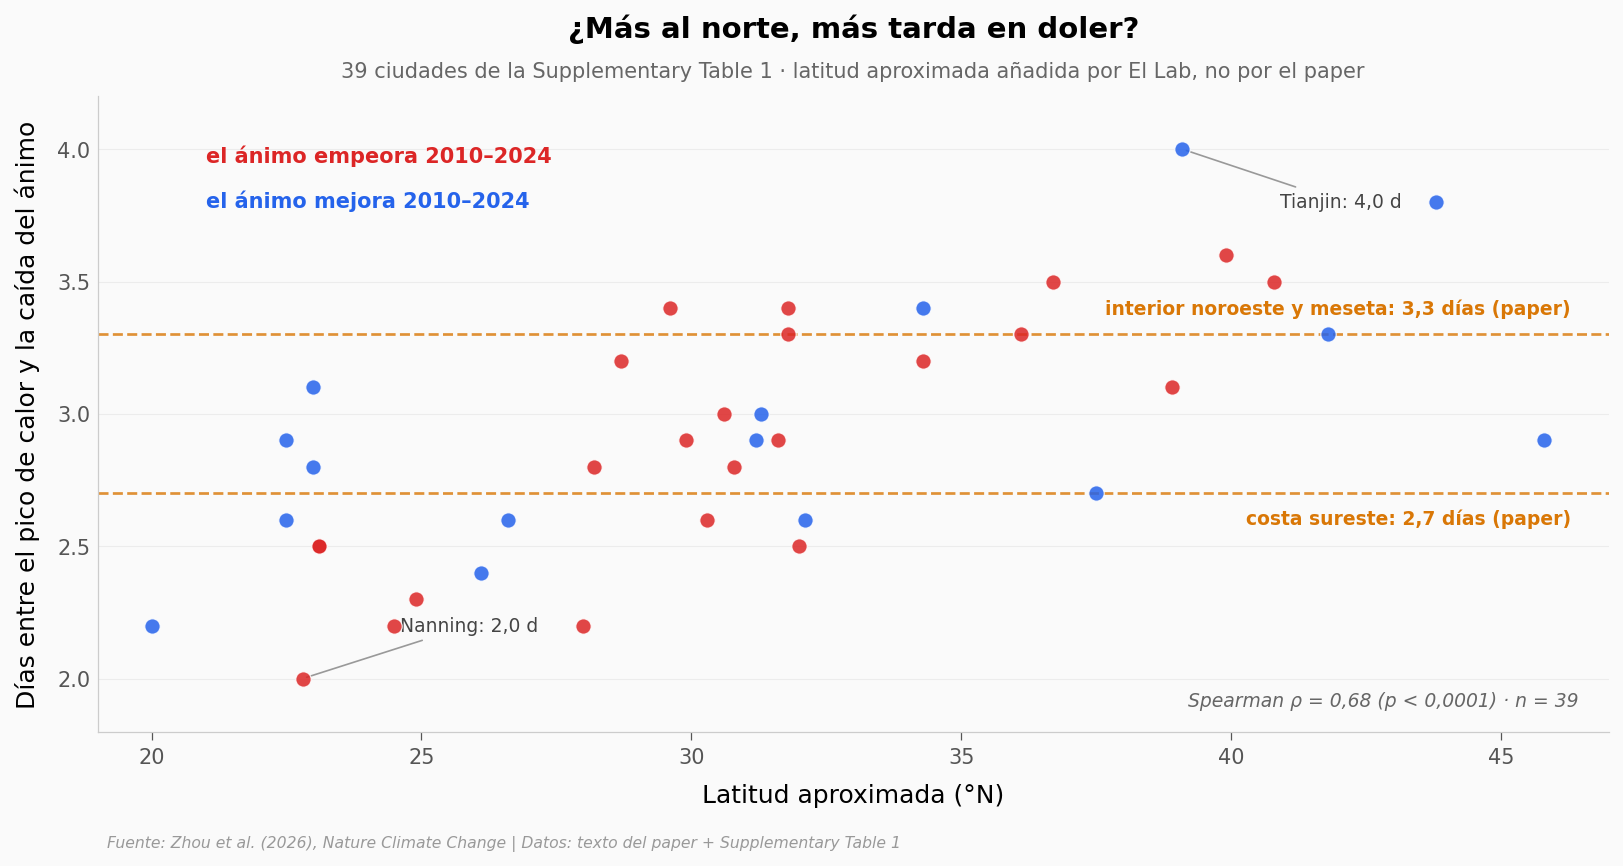

Lag ~ latitud: ρ = 0,68, p = 2.1e-06
Lag ~ longitud: ρ = -0,12, p = 0,48
Tendencia emocional: empeora en 23 ciudades, mejora en 16 (todas con p < 0,05 en Mann-Kendall: True)
Lag donde empeora: 2,90 días · donde mejora: 2,95 días · Cohen's d = 0,10 · Mann-Whitney p = 0,95
Shapiro-Wilk del lag (39 ciudades): p = 0,86


In [3]:
ciudades['tendencia'] = np.where(ciudades['sen_slope_emocion_por_3h'] < 0, 'empeora', 'mejora')
rho_lat, p_lat = stats.spearmanr(ciudades['lat_aprox'], ciudades['mejor_lag_dias'])
rho_lon, p_lon = stats.spearmanr(ciudades['lon_aprox'], ciudades['mejor_lag_dias'])

fig, ax = plt.subplots(figsize=(13, 5.5))
paleta = {'empeora': COLOR_ALERTA, 'mejora': COLOR_DATOS}
for tend, grupo in ciudades.groupby('tendencia'):
    ax.scatter(grupo['lat_aprox'], grupo['mejor_lag_dias'], color=paleta[tend], s=55,
               alpha=0.85, edgecolors='white', linewidths=0.6, zorder=5)

# Referencias regionales del paper (357 ciudades)
costa = lag_region.loc[0, 'mejor_lag_dias']
interior = lag_region.loc[1, 'mejor_lag_dias']
ax.axhline(costa, color=COLOR_REFERENCIA, linewidth=1.3, linestyle='--', alpha=0.8, zorder=1)
ax.axhline(interior, color=COLOR_REFERENCIA, linewidth=1.3, linestyle='--', alpha=0.8, zorder=1)
ax.text(46.3, costa - 0.06, f'costa sureste: {es(costa)} días (paper)', ha='right', va='top',
        fontsize=9, color=COLOR_REFERENCIA, fontweight='bold')
ax.text(46.3, interior + 0.06, f'interior noroeste y meseta: {es(interior)} días (paper)', ha='right',
        va='bottom', fontsize=9, color=COLOR_REFERENCIA, fontweight='bold')

# Extremos con nombre
ext = ciudades.loc[[ciudades['mejor_lag_dias'].idxmin(), ciudades['mejor_lag_dias'].idxmax()]]
for _, r in ext.iterrows():
    ax.annotate(f"{r['ciudad']}: {es(r['mejor_lag_dias'])} d", xy=(r['lat_aprox'], r['mejor_lag_dias']),
                xytext=(r['lat_aprox'] + 1.8, r['mejor_lag_dias'] + (0.18 if r['mejor_lag_dias'] < 3 else -0.22)),
                fontsize=9, color='#444444', arrowprops=dict(arrowstyle='-', color='#999999', lw=0.8))

# Etiquetas inline en vez de leyenda
ax.text(21.0, 3.95, 'el ánimo empeora 2010–2024', fontsize=10, color=COLOR_ALERTA, fontweight='bold')
ax.text(21.0, 3.78, 'el ánimo mejora 2010–2024', fontsize=10, color=COLOR_DATOS, fontweight='bold')
ax.text(0.98, 0.04, f'Spearman ρ = {es(rho_lat, 2)} (p < 0,0001) · n = {len(ciudades)}',
        transform=ax.transAxes, ha='right', fontsize=9, color='#666666', style='italic')

ax.set_xlim(19, 47)
ax.set_ylim(1.8, 4.2)
ax.set_xlabel('Latitud aproximada (°N)')
ax.set_ylabel('Días entre el pico de calor y la caída del ánimo')
ax.set_title('¿Más al norte, más tarda en doler?', fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, '39 ciudades de la Supplementary Table 1 · latitud aproximada añadida por El Lab, no por el paper',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')
fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/lag_vs_latitud.png', dpi=200, bbox_inches='tight')
plt.show()

print(f'Lag ~ latitud: ρ = {es(rho_lat, 2)}, p = {p_lat:.1e}')
print(f'Lag ~ longitud: ρ = {es(rho_lon, 2)}, p = {es(p_lon, 2)}')
print(f'Tendencia emocional: empeora en {(ciudades.tendencia == "empeora").sum()} ciudades, '
      f'mejora en {(ciudades.tendencia == "mejora").sum()} (todas con p < 0,05 en Mann-Kendall: '
      f'{(ciudades.p_valor < 0.05).all()})')
emp = ciudades.loc[ciudades.tendencia == 'empeora', 'mejor_lag_dias']
mej = ciudades.loc[ciudades.tendencia == 'mejora', 'mejor_lag_dias']
sd_pool = np.sqrt(((len(emp) - 1) * emp.var(ddof=1) + (len(mej) - 1) * mej.var(ddof=1)) / (len(emp) + len(mej) - 2))
d_sen = (mej.mean() - emp.mean()) / sd_pool
print(f'Lag donde empeora: {es(emp.mean(), 2)} días · donde mejora: {es(mej.mean(), 2)} días · '
      f"Cohen's d = {es(d_sen, 2)} · Mann-Whitney p = {es(stats.mannwhitneyu(emp, mej).pvalue, 2)}")
print(f'Shapiro-Wilk del lag (39 ciudades): p = {es(stats.shapiro(ciudades.mejor_lag_dias).pvalue, 2)}')

El gradiente aparece: cuanto más al norte, más días pasan entre el pico de calor y el bajón (ρ de Spearman = 0,68, p < 0,0001, n = 39). Nanning, en el sur tropical, reacciona en 2,0 días; Tianjin, en el norte, en 4,0. La longitud no cuenta la misma historia (ρ = −0,12, p = 0,48): en estas 39 ciudades el eje es sur–norte, no costa–interior en sentido este–oeste. Ojo con la letra pequeña: las coordenadas son nuestras y aproximadas, y las dos líneas de referencia vienen del análisis del paper sobre 357 ciudades, no de este subconjunto.

Hay una segunda lectura que **no** cuadra tan bien. En 23 de las 39 ciudades el ánimo veraniego empeoró entre 2010 y 2024 y en 16 mejoró (todas con p < 0,05 en Mann-Kendall; la mayor es p = 0,048). Uno esperaría que las ciudades que empeoran fueran las que tardan más en reaccionar. No: 2,90 días donde empeora frente a 2,95 donde mejora, *d* de Cohen = 0,10, Mann-Whitney p = 0,95. En este subconjunto, la espera y el deterioro van por caminos separados.

## ¿Qué mueve cada índice?

El paper entrena un modelo de aprendizaje automático (LightGBM) y luego reparte el mérito de la predicción entre 20 variables con una técnica llamada valores SHAP — cuánto aporta cada una a la resiliencia física y a la emocional. Es una atribución correlacional, no un experimento, y así la leemos.

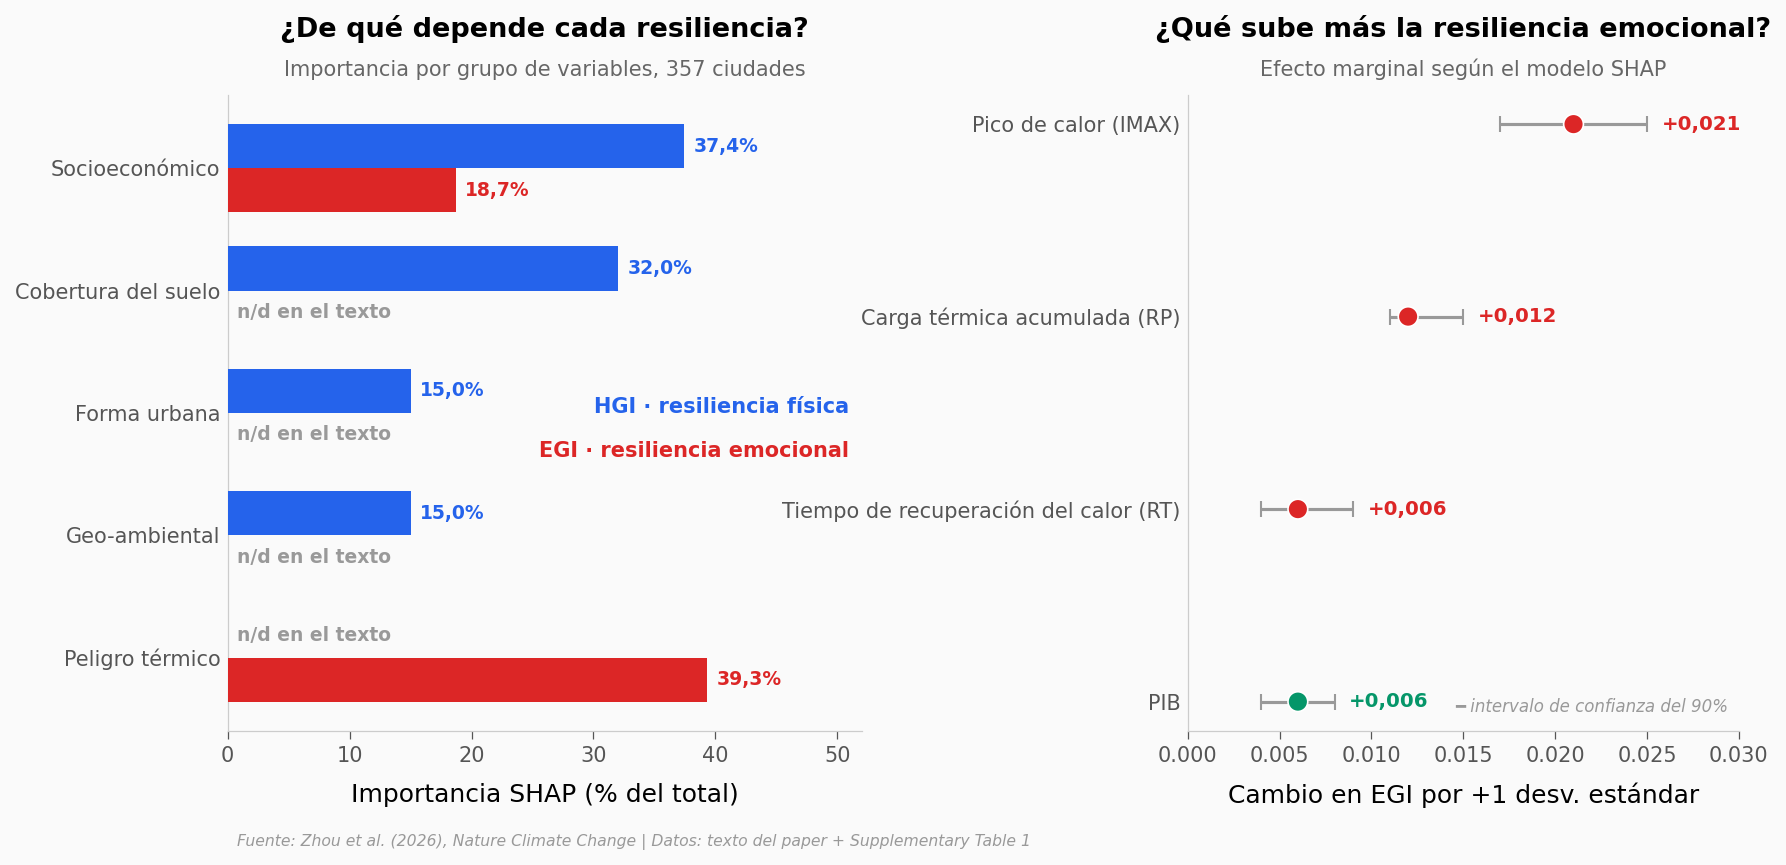

Pico de calor: +0,021 · PIB: +0,006 · cociente 3,5× (cálculo del Lab)


In [4]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5.5), gridspec_kw={'width_ratios': [1.15, 1]})

# Panel izquierdo: importancia por grupo de variables
grupos = shap[shap['tipo'] == 'grupo'].pivot(index='feature_o_grupo', columns='modelo', values='importancia_pct')
orden = ['Socioeconomico', 'Cobertura de suelo', 'Forma urbana', 'Geo-ambiental', 'Peligro termico (IMAX_h+RP_h+RT_h)']
nombres = ['Socioeconómico', 'Cobertura del suelo', 'Forma urbana', 'Geo-ambiental', 'Peligro térmico']
grupos = grupos.reindex(orden)
ypos = np.arange(len(orden))[::-1]
h = 0.36
ax1.barh(ypos + h / 2, grupos['HGI'].fillna(0), height=h, color=COLOR_DATOS, zorder=3)
ax1.barh(ypos - h / 2, grupos['EGI'].fillna(0), height=h, color=COLOR_ALERTA, zorder=3)
for yi, (hg, eg) in zip(ypos, zip(grupos['HGI'], grupos['EGI'])):
    ax1.text((hg if pd.notna(hg) else 0) + 0.8, yi + h / 2, f'{es(hg)}%' if pd.notna(hg) else 'n/d en el texto',
             va='center', fontsize=9, color=COLOR_DATOS if pd.notna(hg) else '#999999', fontweight='bold')
    ax1.text((eg if pd.notna(eg) else 0) + 0.8, yi - h / 2, f'{es(eg)}%' if pd.notna(eg) else 'n/d en el texto',
             va='center', fontsize=9, color=COLOR_ALERTA if pd.notna(eg) else '#999999', fontweight='bold')
ax1.set_yticks(ypos)
ax1.set_yticklabels(nombres, fontsize=10)
ax1.set_xlim(0, 52)
ax1.set_xlabel('Importancia SHAP (% del total)')
ax1.grid(axis='y', visible=False)
ax1.text(0.98, 0.50, 'HGI · resiliencia física', transform=ax1.transAxes, ha='right', fontsize=10,
         color=COLOR_DATOS, fontweight='bold')
ax1.text(0.98, 0.43, 'EGI · resiliencia emocional', transform=ax1.transAxes, ha='right', fontsize=10,
         color=COLOR_ALERTA, fontweight='bold')
ax1.set_title('¿De qué depende cada resiliencia?', fontsize=13, fontweight='bold', pad=28)
ax1.text(0.5, 1.03, 'Importancia por grupo de variables, 357 ciudades', transform=ax1.transAxes,
         fontsize=10, color='#666666', ha='center')

# Panel derecho: efecto de +1 desviación estándar sobre EGI (cuartil superior)
efectos = shap[(shap['modelo'] == 'EGI') & (shap['tipo'] == 'feature')].copy()
etq = {'IMAX_h (pico de calor)': 'Pico de calor (IMAX)',
       'RP_h (carga acumulada)': 'Carga térmica acumulada (RP)',
       'RT_h (tiempo recuperacion calor)': 'Tiempo de recuperación del calor (RT)',
       'GDP': 'PIB'}
efectos['nombre'] = efectos['feature_o_grupo'].map(etq)
efectos = efectos.sort_values('efecto_egi', ascending=True).reset_index(drop=True)
ypos2 = np.arange(len(efectos))
err = np.vstack([efectos['efecto_egi'] - efectos['ci90_bajo'], efectos['ci90_alto'] - efectos['efecto_egi']])
col2 = [COLOR_SECUNDARIO if 'PIB' in n else COLOR_ALERTA for n in efectos['nombre']]
ax2.errorbar(efectos['efecto_egi'], ypos2, xerr=err, fmt='none', ecolor='#999999', elinewidth=1.5, capsize=4, zorder=4)
ax2.scatter(efectos['efecto_egi'], ypos2, color=col2, s=90, edgecolors='white', linewidths=0.8, zorder=5)
for yi, v, hi, c in zip(ypos2, efectos['efecto_egi'], efectos['ci90_alto'], col2):
    ax2.text(hi + 0.0008, yi, f'+{es(v, 3)}', ha='left', va='center', fontsize=9.5, color=c, fontweight='bold')
ax2.set_yticks(ypos2)
ax2.set_yticklabels(efectos['nombre'], fontsize=10)
ax2.set_xlim(0, 0.03)
ax2.set_xlabel('Cambio en EGI por +1 desv. estándar')
ax2.grid(axis='y', visible=False)
ax2.text(0.98, 0.03, '━ intervalo de confianza del 90%', transform=ax2.transAxes, ha='right',
         fontsize=8, color='#999999', style='italic')
ax2.set_title('¿Qué sube más la resiliencia emocional?', fontsize=13, fontweight='bold', pad=28)
ax2.text(0.5, 1.03, 'Efecto marginal según el modelo SHAP', transform=ax2.transAxes,
         fontsize=10, color='#666666', ha='center')

plt.subplots_adjust(wspace=0.55)
fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/importancia_shap.png', dpi=200, bbox_inches='tight')
plt.show()

imax = efectos.loc[efectos['nombre'] == 'Pico de calor (IMAX)', 'efecto_egi'].iloc[0]
pib = efectos.loc[efectos['nombre'] == 'PIB', 'efecto_egi'].iloc[0]
print(f'Pico de calor: +{es(imax, 3)} · PIB: +{es(pib, 3)} · cociente {es(imax / pib, 1)}× (cálculo del Lab)')

Las dos resiliencias se apoyan en cosas distintas. La física la explican sobre todo la economía (37,4% de la importancia) y la cobertura del suelo (32,0%): las ciudades ricas y con vegetación tienden a enfriarse antes. La emocional responde al peligro térmico en sí — pico, carga acumulada y tiempo de recuperación del calor suman el 39,3% — y a la economía mucho menos (18,7%). El texto del paper no desglosa los otros grupos para EGI; el resto de la barra no existe porque el dato no está, no porque valga cero.

En el panel derecho hay algo contraintuitivo: según el modelo, subir una desviación estándar el pico de calor eleva el índice emocional en 0,021, mientras que la misma subida en PIB lo eleva 0,006 — 3,5 veces menos (cociente nuestro). Las ciudades más golpeadas por el calor extremo parecen tener un ánimo que se recupera mejor, como si la exposición repetida amortiguara. Es una lectura del modelo, no una causa demostrada.

## ¿Y de aquí a 2050?

El paper proyecta ambos índices con 13 modelos climáticos CMIP6 bajo tres escenarios socioeconómicos. El titular del resumen: la resiliencia emocional cae «un 26% más rápido» que la física. Veamos de dónde sale ese número.

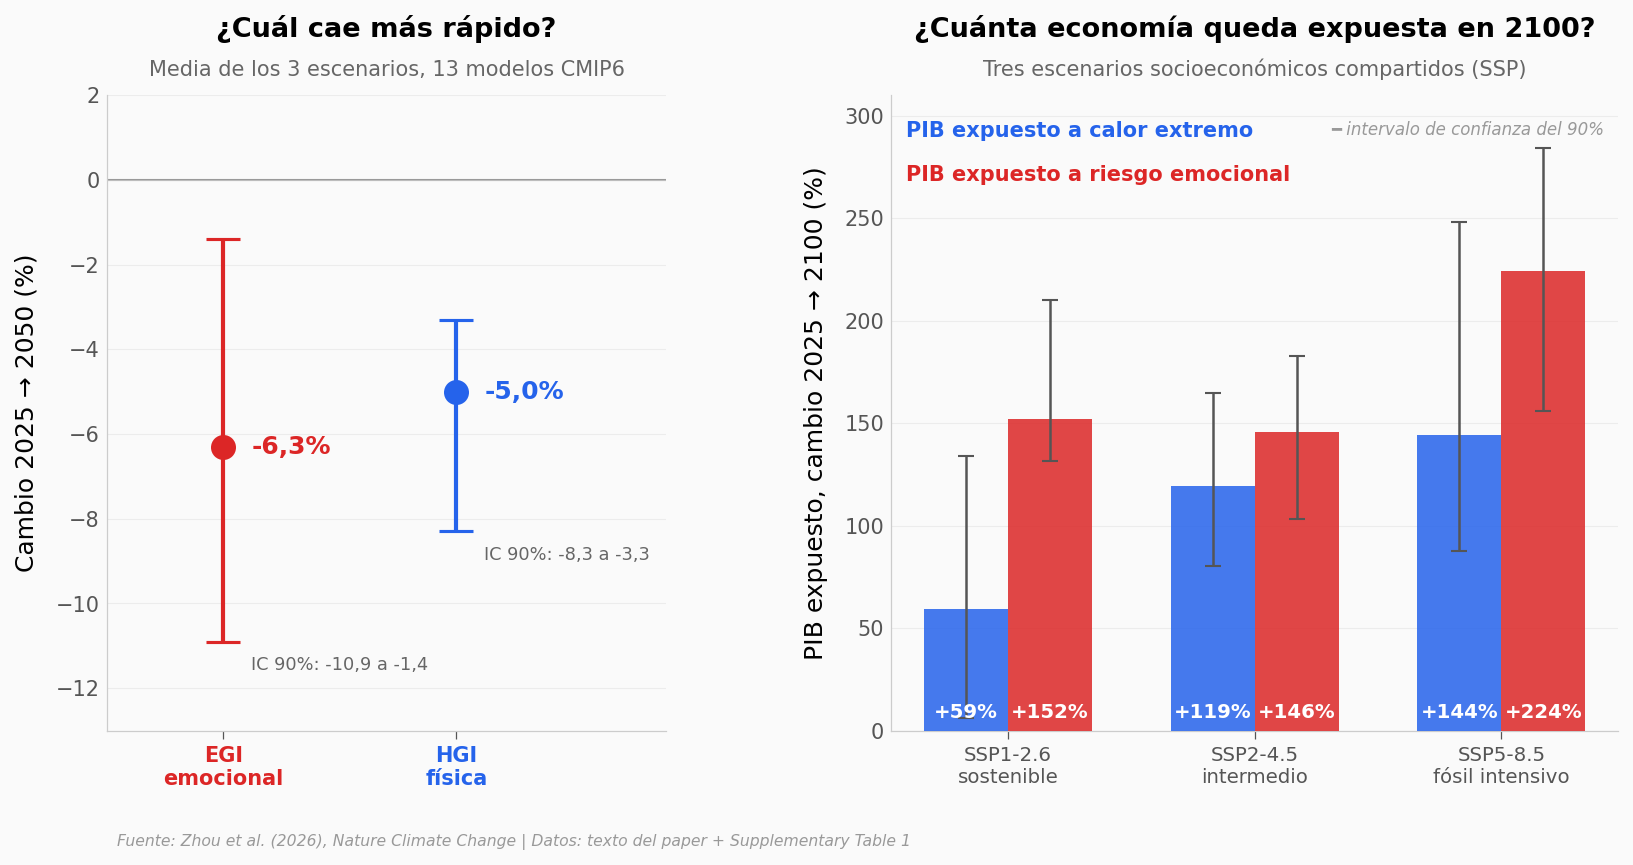

EGI -6,3% vs HGI -5,0% → cociente 1,26 ("~26% más rápido")
Solapamiento de los IC 90%: EGI [-10,9, -1,4] vs HGI [-8,3, -3,3]


In [5]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5.5), gridspec_kw={'width_ratios': [1, 1.3]})

# Panel izquierdo: cambio 2025-2050 de EGI y HGI (media de los 3 escenarios), CI 90%
corto = proy[proy['periodo'] == '2025-2050'].set_index('variable')
xs = [0, 1]
cols = [COLOR_ALERTA, COLOR_DATOS]
for xi, var, c in zip(xs, ['EGI', 'HGI'], cols):
    v, lo, hi = corto.loc[var, ['cambio_pct', 'ci90_bajo', 'ci90_alto']]
    ax1.errorbar(xi, v, yerr=[[v - lo], [hi - v]], fmt='o', color=c, markersize=11,
                 ecolor=c, elinewidth=2, capsize=8, capthick=1.5, zorder=5)
    ax1.text(xi + 0.12, v, f'{es(v)}%', va='center', fontsize=12, fontweight='bold', color=c)
    ax1.text(xi + 0.12, lo - 0.35, f'IC 90%: {es(lo)} a {es(hi)}', va='top', fontsize=8.5, color='#666666')
ax1.axhline(0, color='#999999', linewidth=1, zorder=1)
ax1.set_xlim(-0.5, 1.9)
ax1.set_xticks(xs)
ax1.set_xticklabels(['EGI\nemocional', 'HGI\nfísica'], fontsize=10, fontweight='bold')
for tick, c in zip(ax1.get_xticklabels(), cols):
    tick.set_color(c)
ax1.set_ylim(-13, 2)
ax1.set_ylabel('Cambio 2025 → 2050 (%)')
ax1.grid(axis='x', visible=False)
ax1.set_title('¿Cuál cae más rápido?', fontsize=13, fontweight='bold', pad=28)
ax1.text(0.5, 1.03, 'Media de los 3 escenarios, 13 modelos CMIP6', transform=ax1.transAxes,
         fontsize=10, color='#666666', ha='center')

# Panel derecho: PIB expuesto en 2100 por escenario
largo = proy[(proy['periodo'] == '2025-2100') & proy['variable'].str.startswith('E_G')].copy()
largo['serie'] = np.where(largo['variable'].str.startswith('E_GH'), 'calor', 'riesgo emocional')
escenarios = ['SSP1-2.6', 'SSP2-4.5', 'SSP5-8.5']
xpos = np.arange(len(escenarios))
w = 0.34
for off, serie, c in [(-w / 2, 'calor', COLOR_DATOS), (w / 2, 'riesgo emocional', COLOR_ALERTA)]:
    sub = largo[largo['serie'] == serie].set_index('escenario').reindex(escenarios)
    ax2.bar(xpos + off, sub['cambio_pct'], width=w, color=c, alpha=0.85, zorder=3)
    ax2.errorbar(xpos + off, sub['cambio_pct'],
                 yerr=[sub['cambio_pct'] - sub['ci90_bajo'], sub['ci90_alto'] - sub['cambio_pct']],
                 fmt='none', ecolor='#555555', elinewidth=1.2, capsize=4, zorder=4)
    for xi, v in zip(xpos + off, sub['cambio_pct']):
        ax2.text(xi, 4, f'+{es(v, 0)}%', ha='center', va='bottom', fontsize=9.5, color='white', fontweight='bold', zorder=5)
ax2.set_xticks(xpos)
ax2.set_xticklabels(['SSP1-2.6\nsostenible', 'SSP2-4.5\nintermedio', 'SSP5-8.5\nfósil intensivo'], fontsize=9.5)
ax2.set_ylim(0, 310)
ax2.set_ylabel('PIB expuesto, cambio 2025 → 2100 (%)')
ax2.grid(axis='x', visible=False)
ax2.text(0.02, 0.96, 'PIB expuesto a calor extremo', transform=ax2.transAxes, va='top', fontsize=10,
         color=COLOR_DATOS, fontweight='bold')
ax2.text(0.02, 0.89, 'PIB expuesto a riesgo emocional', transform=ax2.transAxes, va='top', fontsize=10,
         color=COLOR_ALERTA, fontweight='bold')
ax2.text(0.98, 0.96, '━ intervalo de confianza del 90%', transform=ax2.transAxes, ha='right', va='top',
         fontsize=8, color='#999999', style='italic')
ax2.set_title('¿Cuánta economía queda expuesta en 2100?', fontsize=13, fontweight='bold', pad=28)
ax2.text(0.5, 1.03, 'Tres escenarios socioeconómicos compartidos (SSP)', transform=ax2.transAxes,
         fontsize=10, color='#666666', ha='center')

plt.subplots_adjust(wspace=0.35)
fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/proyecciones_2050_2100.png', dpi=200, bbox_inches='tight')
plt.show()

egi, hgi = corto.loc['EGI', 'cambio_pct'], corto.loc['HGI', 'cambio_pct']
print(f'EGI {es(egi)}% vs HGI {es(hgi)}% → cociente {es(egi / hgi, 2)} ("~26% más rápido")')
print(f'Solapamiento de los IC 90%: EGI [{es(corto.loc["EGI", "ci90_bajo"])}, {es(corto.loc["EGI", "ci90_alto"])}] '
      f'vs HGI [{es(corto.loc["HGI", "ci90_bajo"])}, {es(corto.loc["HGI", "ci90_alto"])}]')

El «26% más rápido» es el cociente entre dos caídas: −6,3% del índice emocional frente a −5,0% del físico entre 2025 y 2050, y 6,3 / 5,0 = 1,26. El número es correcto. Lo que el panel izquierdo añade es lo que el titular no dice: los intervalos de confianza (−10,9 a −1,4 frente a −8,3 a −3,3) se solapan casi por completo. Las proyecciones apuntan a que lo emocional se erosiona antes, pero la diferencia entre ambas caídas no está estadísticamente separada.

Hacia 2100 la asimetría se ve en la economía expuesta. En el escenario de emisiones más altas (SSP5-8.5), el PIB expuesto a calor extremo crece un 144% y el PIB expuesto a riesgo emocional un 224%. En los tres escenarios la barra roja supera a la azul, pero los intervalos de confianza del 90% se solapan en los tres: en SSP5-8.5, +156 a +284 frente a +87 a +248; en SSP2-4.5, +103 a +183 frente a +81 a +165; en SSP1-2.6 apenas se rozan (+132 a +210 frente a +6 a +134). Igual que en 2050, la dirección es clara y la separación estadística no.

## ¿Qué tan raro es esperar 3,3 días?

Volvamos a las 39 ciudades con lag. ¿Dónde caen las dos referencias regionales del paper dentro de lo que realmente varía entre ciudades?

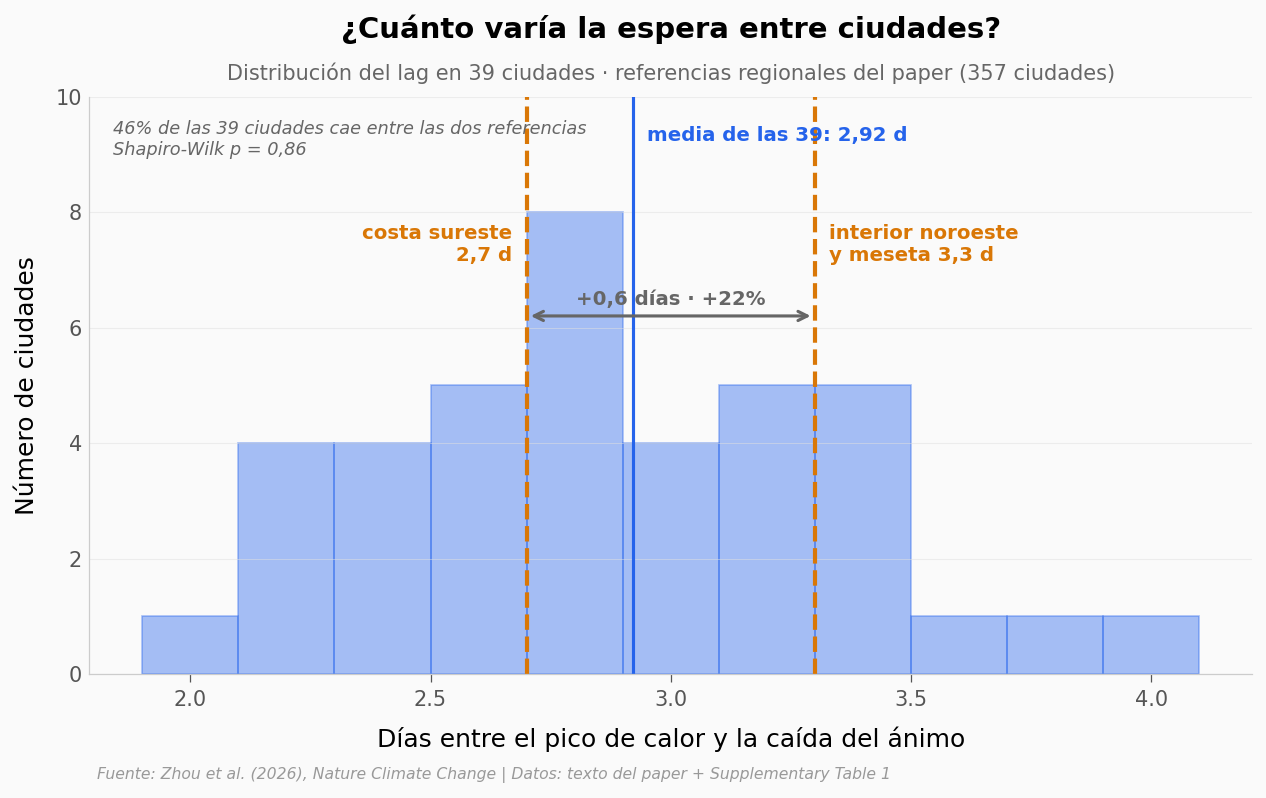

Ciudades con lag entre 2,7 y 3,3 días: 18 de 39 (46%)
Por debajo de 2,7: 13 · por encima de 3,3: 8


In [6]:
lag = ciudades['mejor_lag_dias']
media = lag.mean()

fig, ax = plt.subplots(figsize=(10, 5))
bins = np.arange(1.9, 4.3, 0.2)
n, b, patches = ax.hist(lag, bins=bins, color=COLOR_DATOS, alpha=0.4, edgecolor=COLOR_DATOS, linewidth=0.8)
y_max = n.max() * 1.25
ax.set_ylim(0, y_max)

ax.axvline(media, color=COLOR_DATOS, linewidth=1.5)
ax.text(media + 0.03, y_max * 0.95, f'media de las 39: {es(media, 2)} d', fontsize=9.5,
        color=COLOR_DATOS, fontweight='bold', va='top')
ax.axvline(costa, color=COLOR_REFERENCIA, linewidth=2, linestyle='--')
ax.axvline(interior, color=COLOR_REFERENCIA, linewidth=2, linestyle='--')
ax.text(costa - 0.03, y_max * 0.78, f'costa sureste\n{es(costa)} d', ha='right', va='top',
        fontsize=9.5, color=COLOR_REFERENCIA, fontweight='bold')
ax.text(interior + 0.03, y_max * 0.78, f'interior noroeste\ny meseta {es(interior)} d', ha='left', va='top',
        fontsize=9.5, color=COLOR_REFERENCIA, fontweight='bold')
ax.annotate('', xy=(interior, y_max * 0.62), xytext=(costa, y_max * 0.62),
            arrowprops=dict(arrowstyle='<->', color='#666666', lw=1.5))
ax.text((costa + interior) / 2, y_max * 0.64,
        f'+{es(interior - costa)} días · +{es((interior - costa) / costa * 100, 0)}%',
        ha='center', fontsize=9.5, color='#666666', fontweight='bold')

pct_dentro = ((lag >= costa) & (lag <= interior)).mean() * 100
ax.text(0.02, 0.96, f'{es(pct_dentro, 0)}% de las 39 ciudades cae entre las dos referencias\nShapiro-Wilk p = {es(stats.shapiro(lag).pvalue, 2)}',
        transform=ax.transAxes, ha='left', va='top', fontsize=8.5, color='#666666', style='italic')

ax.set_xlabel('Días entre el pico de calor y la caída del ánimo')
ax.set_ylabel('Número de ciudades')
ax.set_title('¿Cuánto varía la espera entre ciudades?', fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, 'Distribución del lag en 39 ciudades · referencias regionales del paper (357 ciudades)',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')
fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/histograma_lag.png', dpi=200, bbox_inches='tight')
plt.show()

print(f'Ciudades con lag entre {es(costa)} y {es(interior)} días: {((lag >= costa) & (lag <= interior)).sum()} de {len(lag)} ({es(pct_dentro, 0)}%)')
print(f'Por debajo de {es(costa)}: {(lag < costa).sum()} · por encima de {es(interior)}: {(lag > interior).sum()}')

### Lo que los datos soportan

| Afirmación | ¿Soportada? | Detalle |
|------------|-------------|---------|
| El 84,9% de las ciudades sufrió shocks emocionales intensos y el 52,1% exposición física severa | ✅ | Cifras del paper (357 ciudades). El cociente 1,63× es cálculo nuestro. El umbral es la media muestral, así que el 84,9% refleja también la asimetría de la distribución |
| El lag emocional crece hacia el norte | ✅ | ρ de Spearman = 0,68, p < 0,0001, n = 39. Coordenadas aproximadas añadidas por El Lab; el paper reporta el gradiente por región (2,7 vs 3,3 días), no por latitud |
| Las ciudades donde el ánimo empeora tardan más en reaccionar | ❌ | 2,90 vs 2,95 días, *d* = 0,10, Mann-Whitney p = 0,95 en las 39 ciudades. No se ve |
| La resiliencia física depende de economía y suelo; la emocional, del calor en sí | ⚠️ | Importancias SHAP del paper (37,4% + 32,0% vs 39,3%). Atribución de un modelo correlacional; el paper lo enmarca como *driven by*, no como causa |
| La resiliencia emocional cae ~26% más rápido que la física hasta 2050 | ⚠️ | 6,3 / 5,0 = 1,26 con las cifras del paper, pero los IC 90% (−10,9 a −1,4 vs −8,3 a −3,3) se solapan. Las proyecciones *apuntan a* la divergencia, no la separan estadísticamente |
| Hacia 2100 el PIB expuesto a riesgo emocional crece más que el expuesto a calor | ⚠️ | SSP5-8.5: +224% vs +144%, pero los IC 90% se solapan en los tres escenarios (SSP5-8.5: 156–284 vs 87–248; SSP2-4.5: 103–183 vs 81–165). Proyección, no observación |

> **Limitaciones:** (1) Los datos aquí son valores publicados en el texto del paper y en la Supplementary Table 1, no el dataset de 11 millones de comentarios — replicamos sus cifras, no sus cálculos. (2) Las 39 ciudades de la tabla son un subconjunto no aleatorio (las de mayor población) de las 357; el título de esa tabla dice 40 y lista 39. (3) Latitud y longitud son aproximadas y las añadimos nosotros. (4) Weibo mide ánimo *expresado* por quien publica, no el estado emocional de la población. (5) Estudio observacional: las importancias SHAP no establecen causas. (6) El paper reporta dos HGI de 2010 que parecen contradictorios — 0,728 (media de 19 aglomeraciones) y 0,260 (media de las 357 ciudades). No se comparan entre sí y por eso no graficamos la trayectoria 2010–2024.

## Ahora tú

1. **¿Se sostiene el gradiente si partes las 39 ciudades por la mitad?** Cambia `LAT_CORTE` en la celda de configuración (prueba 25, 30 y 35) y mira cómo cambian la diferencia de medias y la *d* de Cohen en la celda de abajo.
2. **¿Qué ciudad se sale más de la tendencia?** Ajusta una recta `np.polyfit(ciudades.lat_aprox, ciudades.mejor_lag_dias, 1)` y ordena los residuos con `.abs().sort_values()`. ¿Cuál se sale más? ¿Es la que esperabas?
3. **¿Cuánto cambia el «26% más rápido» si usas los extremos de los intervalos?** Con `proy`, calcula el cociente EGI/HGI usando `ci90_bajo` de uno y `ci90_alto` del otro. ¿Puede ser menor que 1?

In [7]:
# --- EXPERIMENTA AQUÍ ---
# ¿Cuánto cambia el lag al norte y al sur de LAT_CORTE?
norte = ciudades.loc[ciudades['lat_aprox'] >= LAT_CORTE, 'mejor_lag_dias']
sur = ciudades.loc[ciudades['lat_aprox'] < LAT_CORTE, 'mejor_lag_dias']
sd_pool = np.sqrt(((len(norte) - 1) * norte.var(ddof=1) + (len(sur) - 1) * sur.var(ddof=1)) / (len(norte) + len(sur) - 2))
d = (norte.mean() - sur.mean()) / sd_pool
p_mw = stats.mannwhitneyu(norte, sur).pvalue

print(f'Corte en {es(LAT_CORTE, 0)}°N')
print(f'  Sur   (n={len(sur):2d}): lag medio {es(sur.mean(), 2)} días, mediana {es(sur.median(), 2)}')
print(f'  Norte (n={len(norte):2d}): lag medio {es(norte.mean(), 2)} días, mediana {es(norte.median(), 2)}')
print(f"  Diferencia: +{es(norte.mean() - sur.mean(), 2)} días · Cohen's d = {es(d, 2)} · Mann-Whitney p = {p_mw:.1e}")

Corte en 30°N
  Sur   (n=17): lag medio 2,62 días, mediana 2,60
  Norte (n=22): lag medio 3,15 días, mediana 3,15
  Diferencia: +0,53 días · Cohen's d = 1,32 · Mann-Whitney p = 5.6e-04


---

## Fuentes

**Paper**: [Divergence between physical and emotional heat resilience in Chinese cities](https://doi.org/10.1038/s41558-026-02732-8)  
*Nature Climate Change, 2026-09-11*

**Supplementary Material**: [Supplementary Information for Divergence between physical and emotional heat resilience in Chinese cities (MOESM1, Supplementary Table 1)](https://media.springernature.com/original/springer-static/esm/art%3A10.1038%2Fs41558-026-02732-8/MediaObjects/41558_2026_2732_MOESM1_ESM.pdf)  
*Nature Climate Change, 2026-09-11*

**Referencias citadas**: [Emotion Comments Dataset (11 million geolocated comments, 2010-2024)](https://doi.org/10.6084/m9.figshare.31083328) — citado, no abierto por el notebook (892 MB)

*19 afirmaciones del notebook verificadas contra estas fuentes*

---

*Notebook de [Ciencia a Mordiscos](https://cienciaamordiscos.com). Código y datos: [github.com/Ciencia-a-Mordiscos/lab](https://github.com/Ciencia-a-Mordiscos/lab). Paper: CC BY-NC-ND 4.0. Los CSV de este notebook transcriben cifras publicadas en el paper y su Supplementary Information; las coordenadas aproximadas son de El Lab.*